# PINN experiment notebook

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn

from data_generation import get_initial_condition, get_time_sampling
from net import PINN
from train_test import train_loop

sns.set()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# get the initial conditions, and the training input for the Net
initial_conditions = get_initial_condition()
input = get_time_sampling()
print(initial_conditions)
print(input.shape)

{'time-positon': (0, 1), 'time-speed': (0, 1)}
torch.Size([50, 1])


In [5]:
# get model
model = PINN()
print(model)

PINN(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)


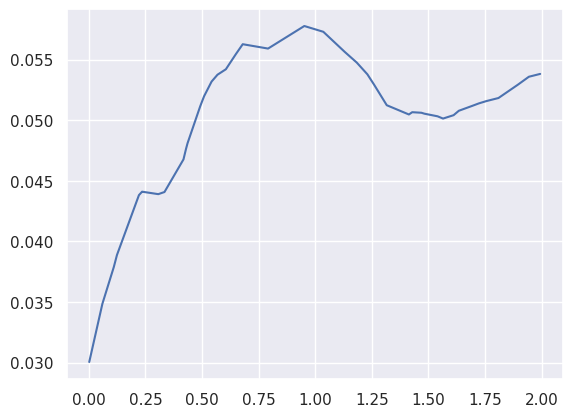

In [6]:
# see initial result for model output
output = model(input)
# As the output is one-dimensional, we can easily visualize it with respect to the input
plt.figure()
plt.plot(input.detach().numpy(), output.detach().numpy())
plt.show()

In [7]:
# define the optimizer
learning_rate = 1e-3
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_loop(input, model, optimizer)

Loss: 0.251739 [   10/    5]
Loss: 0.247528 [   30/    5]
Loss: 0.251369 [   50/    5]


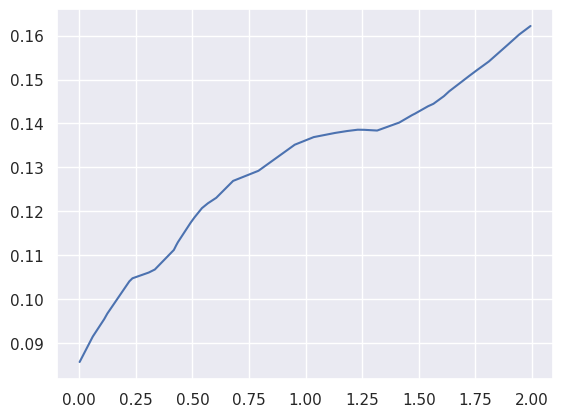

In [9]:
output = model(input)
plt.figure()
plt.plot(input.detach().numpy(), output.detach().numpy())
plt.show()

Epoch 1
----------------------------
Loss: 0.000254 [   10/    5]
Loss: 0.000470 [   30/    5]
Loss: 0.000197 [   50/    5]
Epoch 2
----------------------------
Loss: 0.000387 [   10/    5]
Loss: 0.000308 [   30/    5]
Loss: 0.000237 [   50/    5]
Epoch 3
----------------------------
Loss: 0.000442 [   10/    5]
Loss: 0.000145 [   30/    5]
Loss: 0.000809 [   50/    5]
Epoch 4
----------------------------
Loss: 0.000167 [   10/    5]
Loss: 0.000422 [   30/    5]
Loss: 0.000631 [   50/    5]
Epoch 5
----------------------------
Loss: 0.000533 [   10/    5]
Loss: 0.000289 [   30/    5]
Loss: 0.000292 [   50/    5]
Epoch 6
----------------------------
Loss: 0.000267 [   10/    5]
Loss: 0.000712 [   30/    5]
Loss: 0.000261 [   50/    5]
Epoch 7
----------------------------
Loss: 0.000267 [   10/    5]
Loss: 0.000207 [   30/    5]
Loss: 0.000420 [   50/    5]
Epoch 8
----------------------------
Loss: 0.000408 [   10/    5]
Loss: 0.000524 [   30/    5]
Loss: 0.000295 [   50/    5]
Epoch 9


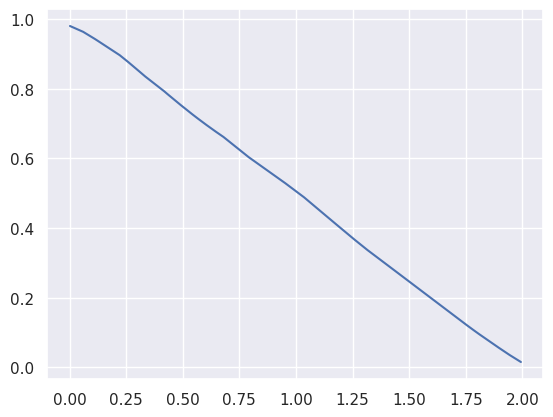

In [17]:
epochs = 10000
for t in range(epochs):
    print(f"Epoch {t+1}\n----------------------------")
    train_loop(input, model, optimizer)
output = model(input)
plt.figure()
plt.plot(input.detach().numpy(), output.detach().numpy())
plt.show()

demora pila en ajustar bien esto, holy shit